# Assignment 1 - Building a Vision Model with Keras

In this assignment, you will build a simple vision model using Keras. The goal is to classify images from the Fashion MNIST dataset, which contains images of clothing items.

You will:
1. Load and inspect the Fashion MNIST dataset.
2. Run a simple baseline model to establish a performance benchmark.
3. Build and evaluate a simple CNN model, choosing appropriate loss and metrics.
4. Design and run controlled experiments on one hyperparameter (e.g., number of filters, kernel size, etc.) and one regularization technique (e.g., dropout, L2 regularization).
5. Analyze the results and visualize the model's performance.

# 1. Loading and Inspecting the Dataset

Fashion MNIST is a dataset of grayscale images of clothing items, with 10 classes. Each image is 28x28 pixels, like the MNIST dataset of handwritten digits. Keras provides a convenient way to load this dataset. 

In this section, you should:

- [ ] Inspect the shapes of the training and test sets to confirm their size and structure.
- [ ] Convert the labels to one-hot encoded format if necessary. (There is a utility function in Keras for this.)
- [ ] Visualize a few images from the dataset to understand what the data looks like.

In [1]:
from tensorflow.keras.datasets import fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Normalize the pixel values to be between 0 and 1
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Classes in the Fashion MNIST dataset
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

In [2]:
# Inspect the shapes of the datasets
print("Training images shape:", X_train.shape)
print("Training labels shape:", y_train.shape)
print("Test images shape:", X_test.shape)
print("Test labels shape:", y_test.shape)

# Convert labels to one-hot encoding
from tensorflow.keras.utils import to_categorical
y_train_cat = to_categorical(y_train, num_classes=10)
y_test_cat = to_categorical(y_test, num_classes=10)

print("Original label:", y_train[0])
print("One-hot encoded label:", y_train_cat[0])


Training images shape: (60000, 28, 28)
Training labels shape: (60000,)
Test images shape: (10000, 28, 28)
Test labels shape: (10000,)
Original label: 9
One-hot encoded label: [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]


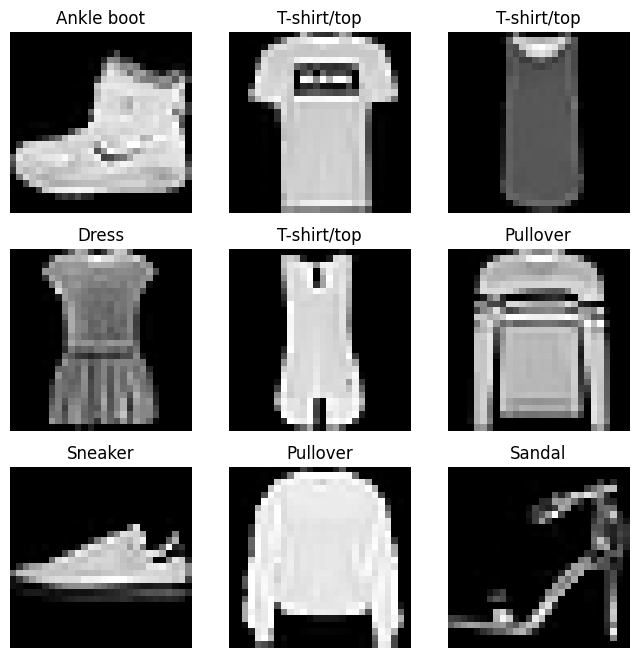

In [3]:
import matplotlib.pyplot as plt
# Verify the data looks as expected

plt.figure(figsize=(8, 8))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(X_train[i], cmap='gray')  # Grayscale image
    plt.title(class_names[y_train[i]])   # Use the original integer label
    plt.axis('off')
plt.show()

Reflection: Does the data look as expected? How is the quality of the images? Are there any issues with the dataset that you notice?

The data looks as expected, each image is a grayscale image of clothing. The issue is that the images are low resolution which causes issues identifying categories like tshirt/top, etc.

# 2. Baseline Model

In this section, you will create a linear regression model as a baseline. This model will not use any convolutional layers, but it will help you understand the performance of a simple model on this dataset.
You should:
- [ ] Create a simple linear regression model using Keras.
- [ ] Compile the model with an appropriate loss function and optimizer.
- [ ] Train the model on the training set and evaluate it on the test set.

A linear regression model can be created using the `Sequential` API in Keras. Using a single `Dense` layer with no activation function is equivalent to a simple linear regression model. Make sure that the number of units in the output layer matches the number of classes in the dataset.

Note that for this step, we will need to use `Flatten` to convert the 2D images into 1D vectors before passing them to the model. Put a `Flatten()` layer as the first layer in your model so that the 2D image data can be flattened into 1D vectors.

In [4]:
from keras.models import Sequential
from keras.layers import Dense, Flatten

# Create a simple linear regression model
model = Sequential()
# You can use `model.add(<layer>)` to add layers to the model
model.add(Flatten(input_shape=(28, 28)))
model.add(Dense(10))
# Compile the model using `model.compile()`
model.compile(
    optimizer = 'sgd',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
# Train the model with `model.fit()`
history = model.fit(
    X_train, y_train_cat,
    epochs=10,
    batch_size=32,
    validation_split=0.1

)
# Evaluate the model with `model.evaluate()`
test_loss_baseline, test_accuracy_baseline = model.evaluate(X_test, y_test_cat)
print(f"Test Accuracy: {test_accuracy_baseline:.4f}")

Epoch 1/10
   1/1688 ━━━━━━━━━━━━━━━━━━━━ 4:04 145ms/step - accuracy: 0.1562 - loss: 6.3970

/Users/chhaganimahima/Desktop/dsi_assignments/deep_learning/deep-learning-env/lib/python3.11/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 578us/step - accuracy: 0.1414 - loss: 7.6365 - val_accuracy: 0.1323 - val_loss: 8.2257
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 484us/step - accuracy: 0.1356 - loss: 8.8894 - val_accuracy: 0.1327 - val_loss: 8.7790
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 494us/step - accuracy: 0.1363 - loss: 9.1119 - val_accuracy: 0.1340 - val_loss: 9.8965
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 476us/step - accuracy: 0.1365 - loss: 10.0029 - val_accuracy: 0.1353 - val_loss: 9.3136
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 460us/step - accuracy: 0.1366 - loss: 9.5668 - val_accuracy: 0.1352 - val_loss: 9.8750
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 505us/step - accuracy: 0.1366 - loss: 9.8930 - val_accuracy: 0.1352 - val_loss: 10.0496
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 450us/step - accuracy: 0.1367 - loss: 9.8849 - val_accuracy: 0.1358 - val_loss: 9.6064
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 503us/step - accuracy: 0.1370 - loss: 9.

Reflection: What is the performance of the baseline model? How does it compare to what you expected? Why do you think the performance is at this level?

The basline model got accuracy of 13.67% which is low. I expected low as we are only adding one layer and not adding activation function like softmax to help the model categorise. The persomance is low as we are using linear regression to categorize complex images.

# 3. Building and Evaluating a Simple CNN Model

In this section, you will build a simple Convolutional Neural Network (CNN) model using Keras. A convolutional neural network is a type of deep learning model that is particularly effective for image classification tasks. Unlike the basic neural networks we have built in the labs, CNNs can accept images as input without needing to flatten them into vectors.

You should:
- [ ] Build a simple CNN model with at least one convolutional layer (to learn spatial hierarchies in images) and one fully connected layer (to make predictions).
- [ ] Compile the model with an appropriate loss function and metrics for a multi-class classification problem.
- [ ] Train the model on the training set and evaluate it on the test set.

Convolutional layers are designed to accept inputs with three dimensions: height, width and channels (e.g., RGB for color images). For grayscale images like those in Fashion MNIST, the input shape will be (28, 28, 1).

When you progress from the convolutional layers to the fully connected layers, you will need to flatten the output of the convolutional layers. This can be done using the `Flatten` layer in Keras, which doesn't require any parameters.

In [5]:
from keras.layers import Conv2D

# Reshape the data to include the channel dimension
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# Create a simple CNN model
simple_cnn = Sequential([
        Conv2D(16, kernel_size=(3,3), activation='relu', input_shape=(28,28,1)),
        Flatten(),
        Dense(10, activation='softmax')
])

# Train the model
simple_cnn.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
history = simple_cnn.fit(
    X_train, y_train_cat,
    epochs=5,
    batch_size=32,
    validation_split=0.1
)

# Evaluate the model
test_loss_simple_cnn, test_acc_simple_cnn = simple_cnn.evaluate(X_test, y_test_cat)
print(f"Test Accuracy: {test_acc_simple_cnn:.4f}")

Epoch 1/5


/Users/chhaganimahima/Desktop/dsi_assignments/deep_learning/deep-learning-env/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8498 - loss: 0.4298 - val_accuracy: 0.8813 - val_loss: 0.3304
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8940 - loss: 0.2972 - val_accuracy: 0.8902 - val_loss: 0.3008
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9071 - loss: 0.2604 - val_accuracy: 0.8983 - val_loss: 0.2888
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9162 - loss: 0.2333 - val_accuracy: 0.8990 - val_loss: 0.2849
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9234 - loss: 0.2144 - val_accuracy: 0.8990 - val_loss: 0.2843
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 696us/step - accuracy: 0.8953 - loss: 0.2945
Test Accuracy: 0.8953


Reflection: Did the CNN model perform better than the baseline model? If so, by how much? What do you think contributed to this improvement?

Yes, CNN performed better by approx 75%. This is because convolutional layer helps model to learn spatial patterns and local feature in the image by filtering and breaking them down into only most important features for classification.

# 3. Designing and Running Controlled Experiments

In this section, you will design and run controlled experiments to improve the model's performance. You will focus on one hyperparameter and one regularization technique.
You should:
- [ ] Choose one hyperparameter to experiment with (e.g., number of filters, kernel size, number of layers, etc.) and one regularization technique (e.g., dropout, L2 regularization). For your hyperparameter, you should choose at least three different values to test (but there is no upper limit). For your regularization technique, simply test the presence or absence of the technique.
- [ ] Run experiments by modifying the model architecture or hyperparameters, and evaluate the performance of each model on the test set.
- [ ] Record the results of your experiments, including the test accuracy and any other relevant metrics.
- [ ] Visualize the results of your experiments using plots or tables to compare the performance of different models.

The best way to run your experiments is to create a `for` loop that iterates over a range of values for the hyperparameter you are testing. For example, if you are testing different numbers of filters, you can create a loop that runs the model with 32, 64, and 128 filters. Within the loop, you can compile and train the model, then evaluate it on the test set. After each iteration, you can store the results in a list or a dictionary for later analysis.

Note: It's critical that you re-initialize the model (by creating a new instance of the model) before each experiment. If you don't, the model will retain the weights from the previous experiment, which can lead to misleading results.

In [ ]:
# A. Test Hyperparameters
from keras.layers import Conv2D
from concurrent.futures import ThreadPoolExecutor

def train_cnn(params):
    filters, kernel = params

    from keras.models import Sequential
    from keras.layers import Conv2D, Flatten, Dense

    cnn = Sequential([
        Conv2D(filters, kernel_size=kernel, activation='relu', input_shape=(28,28,1)),
        Flatten(),
        Dense(128, activation='relu'),
        Dense(10, activation='softmax')
    ])
        
    # Compile the model
    cnn.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
        
    # Train the model (use fewer epochs for quick experiments)
    cnn.fit(
        X_train, y_train_cat,
        epochs=5,
        batch_size=32,
        validation_split=0.1, 
    )

    # Evaluate on test set
    test_loss_hyperparametertuning, test_acc_hyperparametertuning = cnn.evaluate(X_test, y_test_cat, verbose=0)
    return (filters,kernel, test_acc_hyperparametertuning)   

# List of hyperparameter combinations
params_list = [(f, k) for f in [16,32,64] for k in [(2,2),(3,3),(5,5)]]

# Run in parallel using threads
results = []
with ThreadPoolExecutor(max_workers=10) as executor:
    results = list(executor.map(train_cnn, params_list))
    
for r in results:
    print(f"Filters: {r[0]}, Kernel: {r[1]}, Test Accuracy: {r[2]:.4f}")

Epoch 1/5
Epoch 1/5
Epoch 1/5
Epoch 1/5
Epoch 1/5
Epoch 1/5
Epoch 1/5
Epoch 1/5
Epoch 1/5
   1/1688 ━━━━━━━━━━━━━━━━━━━━ 1:06:46 2s/step - accuracy: 0.1562 - loss: 2.3074WARNING:tensorflow:5 out of the last 8011 calls to <function TensorFlowTrainer._make_function.<locals>.multi_step_on_iterator at 0x124109760> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 56s 32ms/step - accuracy: 0.8630 - loss: 0.3862 - val_accuracy: 0.8908 - val_loss: 0.3029


In [ ]:
# B. Test presence or absence of regularization

from keras.layers import Conv2D, Dropout
from concurrent.futures import ThreadPoolExecutor
from keras.regularizers import l2


def train_cnn(params):
    dropout_val, l2_val = params
    
    layers = [
        Conv2D(64, kernel_size=(3,3), activation='relu', input_shape=(28,28,1),
               kernel_regularizer=l2(l2_val) if l2_val else None),
        Flatten(),
        Dense(128, activation='relu', kernel_regularizer=l2(l2_val) if l2_val else None)
    ]
    
    if dropout_val is not None and dropout_val > 0:
        layers.append(Dropout(dropout_val))
    
    layers.append(Dense(10, activation='softmax'))
    
    cnn = Sequential(layers)
        
    # Compile the model
    cnn.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
        
    # Train the model (use fewer epochs for quick experiments)
    cnn.fit(
        X_train, y_train_cat,
        epochs=5,
        batch_size=64,
        validation_split=0.1, 
    )

    # Evaluate on test set
    test_loss, test_acc = cnn.evaluate(X_test, y_test_cat, verbose=0)
    return (dropout_val,l2_val, test_acc)   

# List of hyperparameter combinations
params_list = [(d, l) for d in [0.0, 0.25, 0.5] for l in [None, 0.001, 0.01]]

# Run in parallel using threads
results = []
with ThreadPoolExecutor(max_workers=10) as executor:
    results = list(executor.map(train_cnn, params_list))
    
for r in results:
    print(f"Dropout: {r[0]}, L2: {r[1]}, Test Accuracy: {r[2]:.4f}")

 388/1688 ━━━━━━━━━━━━━━━━━━━━ 2:55 135ms/step - accuracy: 0.8977 - loss: 0.2675Epoch 1/5
 389/1688 ━━━━━━━━━━━━━━━━━━━━ 2:55 135ms/step - accuracy: 0.8977 - loss: 0.2675Epoch 1/5
 605/1688 ━━━━━━━━━━━━━━━━━━━━ 2:24 133ms/step - accuracy: 0.8478 - loss: 0.5921Epoch 1/5
 578/1688 ━━━━━━━━━━━━━━━━━━━━ 2:31 137ms/step - accuracy: 0.8055 - loss: 0.7781Epoch 1/5
 582/1688 ━━━━━━━━━━━━━━━━━━━━ 2:29 136ms/step - accuracy: 0.8279 - loss: 0.6973Epoch 1/5
Epoch 1/5
 390/1688 ━━━━━━━━━━━━━━━━━━━━ 2:54 135ms/step - accuracy: 0.8654 - loss: 0.3776Epoch 1/5
 579/1688 ━━━━━━━━━━━━━━━━━━━━ 2:31 137ms/step - accuracy: 0.8055 - loss: 0.7781Epoch 1/5
Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 328s 195ms/step - accuracy: 0.8934 - loss: 0.2943 - val_accuracy: 0.8990 - val_loss: 0.2828
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 389s 231ms/step - accuracy: 0.7784 - loss: 0.8586 - val_accuracy: 0.8245 - val_loss: 0.7163
1069/1688 ━━━━━━━━━━━━━━━━━━━━ 2:51 277ms/step - accuracy: 0.7260 - loss: 0.9909Epoch 3/5
1688

In [17]:
import pandas as pd

# Example results (replace with your actual evaluated values)
test_accuracy_baseline = 0.1367
test_acc_simple_cnn = 0.8953

# Suppose hyperparameter tuning results (filters vs kernel)
hyperparam_results = [
    (16,(2,2),0.8998),
    (32,(2,2),0.9012),
    (64,(2,2),0.9053),
    (16, (3,3), 0.8976),
    (32, (3,3), 0.9031),
    (64, (3,3), 0.9096),
    (16,(5,5),0.8992),
    (32,(5,5),0.9003),
    (64,(5,5),0.9017)
]

# Regularization tuning results (dropout vs L2)
regularization_results = [
    (0.0, None, 0.9038),
    (0.25, None, 0.9042),
    (0.5, None, 0.8956),
    (0.0, 0.001, 0.8759),
    (0.25, 0.001, 0.8679),  
    (0.5, 0.001, 0.8632),
    (0.0, 0.01, 0.8386),
    (0.25, 0.01, 0.8286),
    (0.5, 0.01, 0.8142),
]

# Build table rows
rows = []

# Baseline
rows.append({
    "Model": "Baseline",
    "Filters": "-",
    "Kernel": "-",
    "Dropout": "-",
    "L2": "-",
    "Test Accuracy": test_accuracy_baseline
})

# Simple CNN
rows.append({
    "Model": "Simple CNN",
    "Filters": 16,  
    "Kernel": (3,3),  
    "Dropout": "-",
    "L2": "-",
    "Test Accuracy": test_acc_simple_cnn
})

# Hyperparameter tuning
for f, k, acc in hyperparam_results:
    rows.append({
        "Model": "CNN Hyperparameter Tuning",
        "Filters": f,
        "Kernel": k,
        "Dropout": "-",
        "L2": "-",
        "Test Accuracy": acc
    })

# Regularization tuning
for d, l, acc in regularization_results:
    rows.append({
        "Model": "CNN Regularization Tuning",
        "Filters": 64,  
        "Kernel": (3,3),  
        "Dropout": d,
        "L2": l,
        "Test Accuracy": acc
    })

# Create DataFrame
df = pd.DataFrame(rows)

# Display table
print(df)


                        Model Filters  Kernel Dropout     L2  Test Accuracy
0                    Baseline       -       -       -      -         0.1367
1                  Simple CNN      16  (3, 3)       -      -         0.8953
2   CNN Hyperparameter Tuning      16  (2, 2)       -      -         0.8998
3   CNN Hyperparameter Tuning      32  (2, 2)       -      -         0.9012
4   CNN Hyperparameter Tuning      64  (2, 2)       -      -         0.9053
5   CNN Hyperparameter Tuning      16  (3, 3)       -      -         0.8976
6   CNN Hyperparameter Tuning      32  (3, 3)       -      -         0.9031
7   CNN Hyperparameter Tuning      64  (3, 3)       -      -         0.9096
8   CNN Hyperparameter Tuning      16  (5, 5)       -      -         0.8992
9   CNN Hyperparameter Tuning      32  (5, 5)       -      -         0.9003
10  CNN Hyperparameter Tuning      64  (5, 5)       -      -         0.9017
11  CNN Regularization Tuning      64  (3, 3)     0.0   None         0.9038
12  CNN Regu

Reflection: Report on the performance of the models you tested. Did any of the changes you made improve the model's performance? If so, which ones? What do you think contributed to these improvements? Finally, what combination of hyperparameters and regularization techniques yielded the best performance?

Filter 64 and kernal size (3,3) performed the best with approx 90% of accuracy. There wasnt much difference in the results approx 0.1 to 0.01 difference was seen for for relu dense 128 as second last layer. Removing relu reduced the accuracy by a 1% or 2% overall but not much difference. No regularization is needed and if we add, 0.25 for dropout works and l2 not needed. Adding better filter and a layer of relu along with softmax imporved the performance a bit. Filter 64, kernal_size (3,3), adding a dense layer of relu and no regulation or dropuout of 0.25 should be the best result.

# 5. Training Final Model and Evaluation

In this section, you will train the final model using the best hyperparameters and regularization techniques you found in the previous section. You should:
- [ ] Compile the final model with the best hyperparameters and regularization techniques.
- [ ] Train the final model on the training set and evaluate it on the test set.
- [ ] Report the final model's performance on the test set, including accuracy and any other relevant metrics.

In [19]:
from keras.layers import Conv2D

# Create a simple CNN model
final_cnn = Sequential([
        Conv2D(64, kernel_size=(3,3), activation='relu', input_shape=(28,28,1)),
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.25),
        Dense(10, activation='softmax')
])

# Train the model
final_cnn.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
history = final_cnn.fit(
    X_train, y_train_cat,
    epochs=5,
    batch_size=32,
    validation_split=0.1
)

# Evaluate the model
final_test_loss, final_test_acc = final_cnn.evaluate(X_test, y_test_cat)
print(f"Test Accuracy: {final_test_acc:.4f}")

Epoch 1/5


/Users/chhaganimahima/Desktop/dsi_assignments/deep_learning/deep-learning-env/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1688/1688 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - accuracy: 0.8508 - loss: 0.4183 - val_accuracy: 0.8868 - val_loss: 0.3068
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.8941 - loss: 0.2857 - val_accuracy: 0.9007 - val_loss: 0.2720
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.9103 - loss: 0.2393 - val_accuracy: 0.9037 - val_loss: 0.2712
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.9270 - loss: 0.1975 - val_accuracy: 0.9063 - val_loss: 0.2646
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.9364 - loss: 0.1688 - val_accuracy: 0.9088 - val_loss: 0.2938
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9018 - loss: 0.2984
Test Accuracy: 0.9018


Reflection: How does the final model's performance compare to the baseline and the CNN model? What do you think contributed to the final model's performance? If you had time, what other experiments would you run to further improve the model's performance?

The final model performs 1 percent better than CNN while 75-76% better than baseline. If I had time I would have experimented more with layers and dropouts.

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.
### Submission Parameters:
* Submission Due Date: `23:59 PM - 26/10/2025`
* The branch name for your repo should be: `assignment-1`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_1.ipynb)
    * The Lab 1 notebook (labs/lab_1.ipynb)
    * The Lab 2 notebook (labs/lab_2.ipynb)
    * The Lab 3 notebook (labs/lab_3.ipynb)
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/deep_learning/pull/<pr_id>`
* Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.
Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.
If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at `#cohort-7-help-ml`. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.